#수치 미분

In [ ]:
import numpy as np

def mean_squared_error(y, t):
  return 0.5 * np.sum((y-t)**2)

#정답 레이블(원-핫 인코딩)
t = [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]

#신경망의 출력 예1: '2'일 확률이 가장 높다고 추정함(0.6)
y1 = [0.1, 0.05, 0.6, 0.0, 0.05, 0.1, 0.0, 0.1, 0.0, 0.0]

#신경망의 출력 예2: '7'일 확률이 가장 높다고 추정함(0.6)
y2 = [0.1, 0.05, 0.1, 0.0, 0.05, 0.1, 0.0, 0.6, 0.0, 0.0]

e1 = mean_squared_error(np.array(y1), np.array(t))
e2 = mean_squared_error(np.array(y2), np.array(t))

print(e1)
print(e2)

0.09750000000000003
0.5975


In [ ]:
def cross_entropy_error(y, t):
  delta = 1e-7
  return -np.sum(t * np.log(y + delta))

e1 = cross_entropy_error(np.array(y1), np.array(t))
e2 = cross_entropy_error(np.array(y2), np.array(t))

print(e1)
print(e2)

0.510825457099338
2.302584092994546


In [ ]:
# 나쁜 구현의 예
def numerical_diff(f, x):
  h = 10e-50
  reurn (f(x+h) - f(x)) / h


In [ ]:
np.float32(1e-50)

np.float32(0.0)

Text(0, 0.5, 'f(x)')

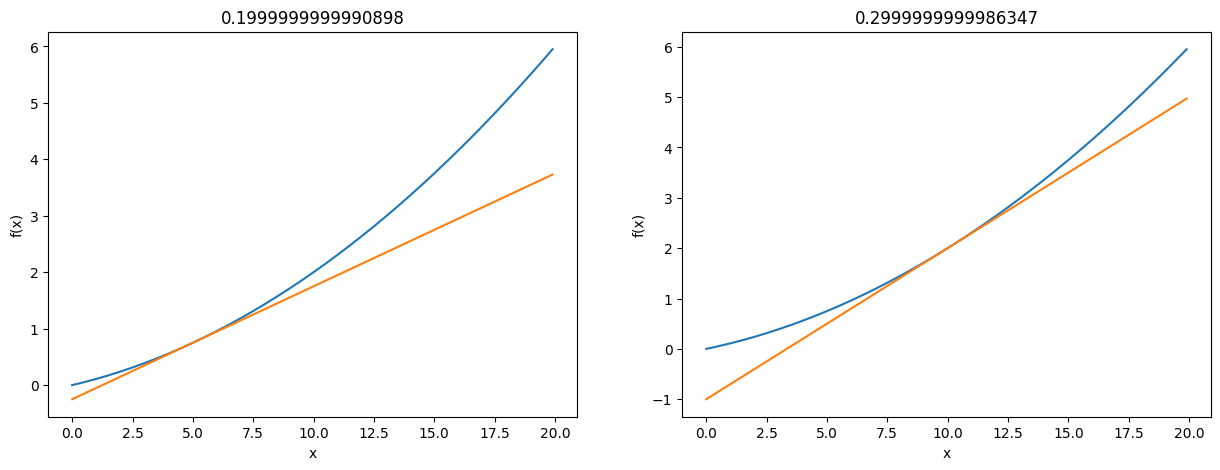

In [ ]:
import numpy as np
import matplotlib.pylab as plt

def numerical_diff(f, x):
  h = 1e-4 # 0.0001
  return (f(x+h) - f(x-h)) / (2*h)

def function_1(x):
  return 0.01*x**2 + 0.1*x

def tangent_line(f, x):
  d = numerical_diff(f, x)
  y = f(x) - d*x
  return lambda t: d*t + y

x = np.arange(0.0, 20.0, 0.1)
y = function_1(x)

fig, axs = plt.subplots(1,2,figsize=(15,5))

tf = tangent_line(function_1, 5)
nd5 = numerical_diff(function_1, 5)
y2 = tf(x)
axs[0].plot(x, y)
axs[0].plot(x, y2)
axs[0].set_title(nd5)
axs[0].set_xlabel("x")
axs[0].set_ylabel("f(x)")


tf = tangent_line(function_1, 10)
nd10 = numerical_diff(function_1, 10)
y3 = tf(x)
axs[1].plot(x, y)
axs[1].plot(x, y3)
axs[1].set_title(nd10)
axs[1].set_xlabel("x")
axs[1].set_ylabel("f(x)")

#편미분

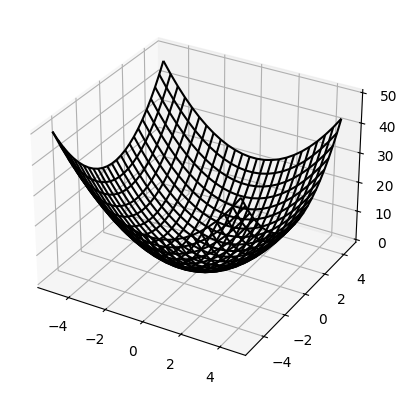

In [ ]:
def function_2(x):
  return x[0]**2 + x[1]**2

X = np.arange(-5, 5, 0.4)
Y = np.arange(-5, 5, 0.4)
X, Y = np.meshgrid(X, Y)

Z = function_2([X,Y])

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
surf = ax.plot_wireframe(X, Y, Z, color='black')

plt.show()

In [ ]:
def function_tmp1(x0):
  return x0*x0 + 4.0**2.0

numerical_diff(function_tmp1, 3)

6.00000000000378

In [ ]:
def function_tmp2(x1):
  return 3.0**2.0 + x1*x1

numerical_diff(function_tmp2, 4.0)

7.999999999999119

In [ ]:
def _numerical_gradient_no_batch(f, x):
    h = 1e-4 # 0.0001
    grad = np.zeros_like(x) # x와 형상이 같은 배열을 생성

    for idx in range(x.size):
        tmp_val = x[idx]

        # f(x+h) 계산
        x[idx] = tmp_val + h
        fxh1 = f(x)

        # f(x-h) 계산
        x[idx] = tmp_val - h
        fxh2 = f(x)

        grad[idx] = (fxh1 - fxh2) / (2*h)
        x[idx] = tmp_val # 값 복원

    return grad

In [ ]:
g1 = _numerical_gradient_no_batch(function_2, np.array([3.0, 4.0]))
g2 = _numerical_gradient_no_batch(function_2, np.array([0.0, 2.0]))
g3 = _numerical_gradient_no_batch(function_2, np.array([3.0, 0.0]))

print(g1)
print(g2)
print(g3)

[6. 8.]
[0. 4.]
[6. 0.]


In [ ]:
def tangent_line(f, x):
    d = numerical_gradient(f, x)
    print(d)
    y = f(x) - d*x
    return lambda t: d*t + y

In [ ]:
def numerical_gradient(f, X):
    if X.ndim == 1:
        return _numerical_gradient_no_batch(f, X)
    else:
        grad = np.zeros_like(X)

        for idx, x in enumerate(X):
            grad[idx] = _numerical_gradient_no_batch(f, x)

        return grad

In [ ]:
X = [3.0, 0.0, 3.0]
Y = [4.0, 2.0, 0.0]
numerical_gradient(function_2, np.array([X, Y]) )

array([[6., 0., 0.],
       [8., 4., 0.]])

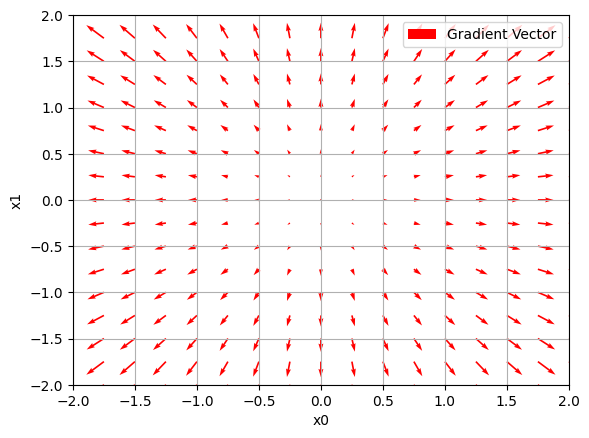

In [ ]:
def function_2(x):
    if x.ndim == 1:
        return np.sum(x**2)
    else:
        return np.sum(x**2, axis=1)


x0 = np.arange(-2, 2.5, 0.25)
x1 = np.arange(-2, 2.5, 0.25)
X, Y = np.meshgrid(x0, x1)

X = X.flatten()
Y = Y.flatten()

grad = numerical_gradient(function_2, np.array([X, Y]) )

plt.figure()
plt.quiver(X, Y, grad[0], grad[1],  angles="xy",color="r", label='Gradient Vector')#,headwidth=10,scale=40,color="#444444")
plt.xlim([-2, 2])
plt.ylim([-2, 2])
plt.xlabel('x0')
plt.ylabel('x1')
plt.grid()
plt.legend()
plt.draw()
plt.show()

#경사하강법

In [ ]:
def gradient_descent(f, init_x, lr=0.01, step_num=100):
    x = init_x
    x_history = []

    for i in range(step_num):
        x_history.append( x.copy() )

        grad = numerical_gradient(f, x)
        x = x - lr * grad

    return x, np.array(x_history)

[[-3.          4.        ]
 [-2.4         3.2       ]
 [-1.92        2.56      ]
 [-1.536       2.048     ]
 [-1.2288      1.6384    ]
 [-0.98304     1.31072   ]
 [-0.786432    1.048576  ]
 [-0.6291456   0.8388608 ]
 [-0.50331648  0.67108864]
 [-0.40265318  0.53687091]
 [-0.32212255  0.42949673]
 [-0.25769804  0.34359738]
 [-0.20615843  0.27487791]
 [-0.16492674  0.21990233]
 [-0.1319414   0.17592186]
 [-0.10555312  0.14073749]
 [-0.08444249  0.11258999]
 [-0.06755399  0.09007199]
 [-0.0540432   0.07205759]
 [-0.04323456  0.05764608]]


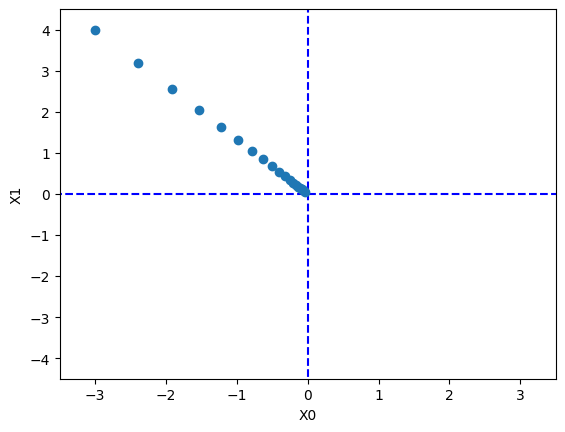

In [ ]:
init_x = np.array([-3.0, 4.0])

lr = 0.1
step_num = 20
x, x_history = gradient_descent(function_2, init_x, lr=lr, step_num=step_num)
print(x_history)

plt.plot( [-5, 5], [0,0], '--b')
plt.plot( [0,0], [-5, 5], '--b')
plt.plot(x_history[:,0], x_history[:,1], 'o')

plt.xlim(-3.5, 3.5)
plt.ylim(-4.5, 4.5)
plt.xlabel("X0")
plt.ylabel("X1")
plt.show()


In [ ]:
def numerical_gradient(f, x):
    h = 1e-4 # 0.0001
    grad = np.zeros_like(x)

    it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
    while not it.finished:
        idx = it.multi_index

        tmp_val = x[idx]

        x[idx] = tmp_val + h
        fxh1 = f(x) # f(x+h)

        x[idx] = tmp_val - h
        fxh2 = f(x) # f(x-h)

        grad[idx] = (fxh1 - fxh2) / (2*h)

        x[idx] = tmp_val # 값 복원

        it.iternext()

    return grad

In [ ]:
import sys, os
import numpy as np

def softmax(a):
  exp_a = np.exp(a)
  sum_exp_a = np.sum(exp_a)
  y = exp_a / sum_exp_a
  return y

def cross_entropy_error(y, t):
  delta = 1e-7
  return -np.sum(t * np.log(y + delta))

def numerical_gradient(f, x):
    h = 1e-4 # 0.0001
    grad = np.zeros_like(x)

    it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
    while not it.finished:
        idx = it.multi_index
        print(idx)
        print(x)

        tmp_val = x[idx]
        x[idx] = float(tmp_val) + h
        print("x+h","\n",x)

        fxh1 = f(x) # f(x+h)
        print("x+h","\n",fxh1)

        x[idx] = tmp_val - h
        print("x-h","\n",x)

        fxh2 = f(x) # f(x-h)
        print("x-h","\n",fxh2)

        grad[idx] = (fxh1 - fxh2) / (2*h)

        print("grad","\n",grad)
        x[idx] = tmp_val # 값 복원
        it.iternext()

    return grad


class simpleNet:
    def __init__(self):
        self.W = np.random.randn(2,3) # 정규분포로 초기화

    def predict(self, x):
        return np.dot(x, self.W)

    def loss(self, x, t):
        z = self.predict(x)
        y = softmax(z)
        loss = cross_entropy_error(y, t)

        return loss

net = simpleNet()
print(net.W, type(net.W))


[[-0.16765492 -0.27990104 -0.13884193]
 [-1.95256986  0.59969183 -0.11234254]] <class 'numpy.ndarray'>


In [ ]:
x = np.asarray([
                [ 0.4,-0.3,0.7],
                [ 0.9,1.8,0.6]
                ])

it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
while not it.finished:
  idx = it.multi_index
  print(idx, x[idx])
  it.iternext()

(0, 0) 0.4
(0, 1) -0.3
(0, 2) 0.7
(1, 0) 0.9
(1, 1) 1.8
(1, 2) 0.6


In [ ]:
x = np.array([0.6, 0.9])
p = net.predict(x)
print(p)

[-0.97745645  1.26564275 -0.2727226 ]


In [ ]:
pi = np.argmax(p)
print(pi)

1


In [ ]:
t = np.array([0, 0, 1])
print(net.loss(x,t))

1.8166484595268166


In [ ]:
def f(W):
  return net.loss(x,t)

dW = numerical_gradient(f, net.W)
print(dW)

(0, 0)
[[-1.78401095 -0.2372528  -0.70410176]
 [ 0.10327791  1.56443825  0.16637606]]
x+h 
 [[-1.78391095 -0.2372528  -0.70410176]
 [ 0.10327791  1.56443825  0.16637606]]
x+h 
 1.8166532805617208
x-h 
 [[-1.78411095 -0.2372528  -0.70410176]
 [ 0.10327791  1.56443825  0.16637606]]
x-h 
 1.8166436387579257
grad 
 [[0.04820902 0.         0.        ]
 [0.         0.         0.        ]]
(0, 1)
[[-1.78401095 -0.2372528  -0.70410176]
 [ 0.10327791  1.56443825  0.16637606]]
x+h 
 [[-1.78401095 -0.2371528  -0.70410176]
 [ 0.10327791  1.56443825  0.16637606]]
x+h 
 1.816693884749177
x-h 
 [[-1.78401095 -0.2373528  -0.70410176]
 [ 0.10327791  1.56443825  0.16637606]]
x-h 
 1.8166030349665272
grad 
 [[0.04820902 0.45424891 0.        ]
 [0.         0.         0.        ]]
(0, 2)
[[-1.78401095 -0.2372528  -0.70410176]
 [ 0.10327791  1.56443825  0.16637606]]
x+h 
 [[-1.78401095 -0.2372528  -0.70400176]
 [ 0.10327791  1.56443825  0.16637606]]
x+h 
 1.816598213978649
x-h 
 [[-1.78401095 -0.2372528  -0

#학습 알고리즘

Convert the original MNIST dataset into JPG format


참고 소스코드: https://github.com/teavanist/MNIST-JPG

아래 사이트에서 파일을 다운받고 압축을 푼 뒤 아래의 4개의 파일을 colab에서 왼쪽 폴더 버튼을 클릭한 후 업로드

the original MNIST dataset: https://www.kaggle.com/datasets/hojjatk/mnist-dataset






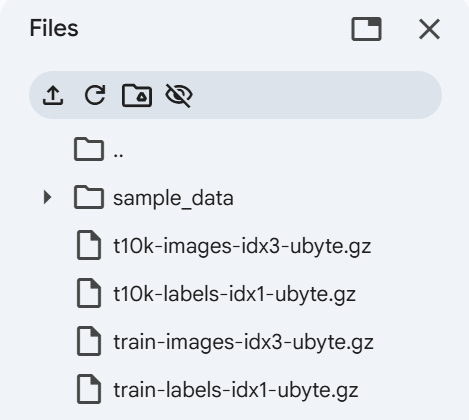

In [5]:
# coding: utf-8
try:
    import urllib.request
except ImportError:
    raise ImportError('You should use Python 3.x')
import os.path
import gzip
import pickle
import os
import numpy as np



key_file = {
    'train_img':'train-images-idx3-ubyte.gz',
    'train_label':'train-labels-idx1-ubyte.gz',
    'test_img':'t10k-images-idx3-ubyte.gz',
    'test_label':'t10k-labels-idx1-ubyte.gz'
}

dataset_dir = "/content"
save_file = dataset_dir + "/mnist.pkl"

train_num = 60000
test_num = 10000
img_dim = (1, 28, 28)
img_size = 784




def _load_label(file_name):
    file_path = dataset_dir + "/" + file_name

    print("Converting " + file_name + " to NumPy Array ...")
    with gzip.open(file_path, 'rb') as f:
            labels = np.frombuffer(f.read(), np.uint8, offset=8)
    print("Done")

    return labels

def _load_img(file_name):
    file_path = dataset_dir + "/" + file_name

    print("Converting " + file_name + " to NumPy Array ...")
    with gzip.open(file_path, 'rb') as f:
            data = np.frombuffer(f.read(), np.uint8, offset=16)
    data = data.reshape(-1, img_size)
    print("Done")

    return data

def _convert_numpy():
    dataset = {}
    dataset['train_img'] =  _load_img(key_file['train_img'])
    dataset['train_label'] = _load_label(key_file['train_label'])
    dataset['test_img'] = _load_img(key_file['test_img'])
    dataset['test_label'] = _load_label(key_file['test_label'])

    return dataset

def init_mnist():
    #download_mnist()
    dataset = _convert_numpy()
    print("Creating pickle file ...")
    with open(save_file, 'wb') as f:
        pickle.dump(dataset, f, -1)
    print("Done!")
    return dataset

def _change_one_hot_label(X):
    T = np.zeros((X.size, 10))
    for idx, row in enumerate(T):
        row[X[idx]] = 1

    return T


def load_mnist(normalize=True, flatten=True, one_hot_label=False):
    """MNIST 데이터셋 읽기

    Parameters
    ----------
    normalize : 이미지의 픽셀 값을 0.0~1.0 사이의 값으로 정규화할지 정한다.
    one_hot_label :
        one_hot_label이 True면、레이블을 원-핫(one-hot) 배열로 돌려준다.
        one-hot 배열은 예를 들어 [0,0,1,0,0,0,0,0,0,0]처럼 한 원소만 1인 배열이다.
    flatten : 입력 이미지를 1차원 배열로 만들지를 정한다.

    Returns
    -------
    (훈련 이미지, 훈련 레이블), (시험 이미지, 시험 레이블)
    """
    if not os.path.exists(save_file):
        init_mnist()

    with open(save_file, 'rb') as f:
        dataset = pickle.load(f)

    if normalize:
        for key in ('train_img', 'test_img'):
            dataset[key] = dataset[key].astype(np.float32)
            dataset[key] /= 255.0

    if one_hot_label:
        dataset['train_label'] = _change_one_hot_label(dataset['train_label'])
        dataset['test_label'] = _change_one_hot_label(dataset['test_label'])

    if not flatten:
         for key in ('train_img', 'test_img'):
            dataset[key] = dataset[key].reshape(-1, 1, 28, 28)

    return (dataset['train_img'], dataset['train_label']), (dataset['test_img'], dataset['test_label'])


dataset = init_mnist()


Converting train-images-idx3-ubyte.gz to NumPy Array ...
Done
Converting train-labels-idx1-ubyte.gz to NumPy Array ...
Done
Converting t10k-images-idx3-ubyte.gz to NumPy Array ...
Done
Converting t10k-labels-idx1-ubyte.gz to NumPy Array ...
Done
Creating pickle file ...
Done!


In [6]:
dataset

{'train_img': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=uint8),
 'train_label': array([5, 0, 4, ..., 5, 6, 8], dtype=uint8),
 'test_img': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=uint8),
 'test_label': array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)}

In [14]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def softmax(x):
    if x.ndim == 2:
        x = x.T
        x = x - np.max(x, axis=0)
        y = np.exp(x) / np.sum(np.exp(x), axis=0)
        return y.T

    x = x - np.max(x) # 오버플로 대책
    return np.exp(x) / np.sum(np.exp(x))
def sigmoid_grad(x):
    return (1.0 - sigmoid(x)) * sigmoid(x)


def numerical_gradient(f, x):
    h = 1e-4 # 0.0001
    grad = np.zeros_like(x)

    it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
    while not it.finished:
        idx = it.multi_index
        tmp_val = x[idx]
        x[idx] = float(tmp_val) + h
        fxh1 = f(x) # f(x+h)

        x[idx] = tmp_val - h
        fxh2 = f(x) # f(x-h)
        grad[idx] = (fxh1 - fxh2) / (2*h)

        x[idx] = tmp_val # 값 복원
        it.iternext()

    return grad


def cross_entropy_error(y, t):

    delta = 1e-7

    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)

    # 훈련 데이터가 원-핫 벡터라면 정답 레이블의 인덱스로 반환
    if t.size == y.size:
        t = t.argmax(axis=1)

    batch_size = y.shape[0]
    qq = y[np.arange(batch_size), t]
    ll = np.log(qq+delta)
    ww = -np.sum(ll)
    return ww / batch_size


class TwoLayerNet:

    def __init__(self, input_size, hidden_size, output_size, weight_init_std=0.001):
        # 가중치 초기화
        self.params = {}
        self.params['W1'] = weight_init_std * np.random.randn(input_size, hidden_size)
        self.params['b1'] = np.zeros(hidden_size)
        self.params['W2'] = weight_init_std * np.random.randn(hidden_size, output_size)
        self.params['b2'] = np.zeros(output_size)

    def predict(self, x):
        W1, W2 = self.params['W1'], self.params['W2']
        b1, b2 = self.params['b1'], self.params['b2']

        a1 = np.dot(x, W1) + b1
        z1 = sigmoid(a1)
        a2 = np.dot(z1, W2) + b2
        y = softmax(a2)

        return y

    # x : 입력 데이터, t : 정답 레이블
    def loss(self, x, t):
        y = self.predict(x)

        return cross_entropy_error(y, t)

    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis=1)
        t = np.argmax(t, axis=1)

        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy

    # x : 입력 데이터, t : 정답 레이블
    def numerical_gradient(self, x, t):
        loss_W = lambda W: self.loss(x, t)

        grads = {}
        grads['W1'] = numerical_gradient(loss_W, self.params['W1'])
        grads['b1'] = numerical_gradient(loss_W, self.params['b1'])
        grads['W2'] = numerical_gradient(loss_W, self.params['W2'])
        grads['b2'] = numerical_gradient(loss_W, self.params['b2'])

        return grads

    def gradient(self, x, t):
        W1, W2 = self.params['W1'], self.params['W2']
        b1, b2 = self.params['b1'], self.params['b2']
        grads = {}

        batch_num = x.shape[0]

        # forward
        a1 = np.dot(x, W1) + b1
        z1 = sigmoid(a1)
        a2 = np.dot(z1, W2) + b2
        y = sigmoid(a2)

        # backward
        dy = (y - t) / batch_num

        grads['W2'] = np.dot(z1.T, dy)
        grads['b2'] = np.sum(dy, axis=0)

        da1 = np.dot(dy, W2.T)
        dz1 = sigmoid_grad(a1) * da1
        grads['W1'] = np.dot(x.T, dz1)
        grads['b1'] = np.sum(dz1, axis=0)

        return grads


In [15]:
import numpy as np
import matplotlib.pyplot as plt

# 데이터 읽기
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

net = TwoLayerNet(input_size=784, hidden_size=100, output_size=10)

In [ ]:
# 하이퍼파라미터
iters_num = 10000  # 반복 횟수를 적절히 설정한다.
train_size = x_train.shape[0]
batch_size = 100   # 미니배치 크기
learning_rate = 0.1

train_loss_list = []
train_acc_list = []
test_acc_list = []

# 1에폭당 반복 수
iter_per_epoch = max(train_size / batch_size, 1)


from scipy.special import expit


for i in range(iters_num):
    # 미니배치 획득
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    # 기울기 계산
    grad = net.numerical_gradient(x_batch, t_batch)
    #grad = net.gradient(x_batch, t_batch)

    # 매개변수 갱신
    for key in ('W1', 'b1', 'W2', 'b2'):
        net.params[key] -= learning_rate * grad[key]

    # 학습 경과 기록
    loss = net.loss(x_batch, t_batch)
    train_loss_list.append(loss)

    # 1에폭당 정확도 계산
    if i % iter_per_epoch == 0:
        train_acc = net.accuracy(x_train, t_train)
        test_acc = net.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        print("Step: {:04d}, Loss: {:.5f}, Train Acc: {:.5f}, Test Acc: {:.5f}".format(i+1, loss, train_acc, test_acc))


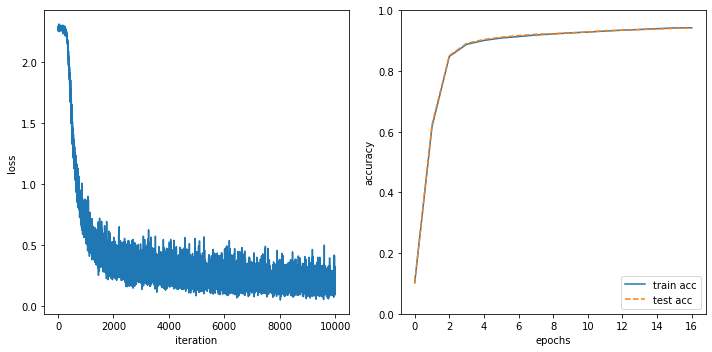

In [ ]:
from IPython.core.pylabtools import figsize
# 그래프 그리기
figsize(10, 5)
markers = {'train': 'o', 'test': 's'}
fig = plt.figure()
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

x_loss = np.arange(len(train_loss_list))
ax1.plot(x_loss, train_loss_list)
ax1.set_xlabel("iteration")
ax1.set_ylabel("loss")

x_acc = np.arange(len(train_acc_list))
ax2.plot(x_acc, train_acc_list, label='train acc')
ax2.plot(x_acc, test_acc_list, label='test acc', linestyle='--')
ax2.set_xlabel("epochs")
ax2.set_ylabel("accuracy")
ax2.set_ylim(0, 1.0)
ax2.legend(loc='lower right')
plt.tight_layout()
plt.show()
